In [1]:
import uproot 
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd
import seaborn as sns
import plotly.express as px
from matplotlib import colors
import math as math
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier, Pool
from catboost.utils import get_roc_curve

In [2]:
total_keys2 = ["L_MASS",'Lb_MASS','Jpsi_MASS','Jpsi_P', "Jpsi_PT",'Jpsi_CHI2','Jpsi_MAXDOCA','Jpsi_BPVDIRA','Jpsi_ETA','Jpsi_END_VRHO','Jpsi_END_VX','Jpsi_END_VY','Jpsi_END_VZ','Jpsi_BPVIP','Jpsi_MINIPCHI2','L_P','L_PT','L_PX','L_PY','L_PZ','L_CHI2',
               'L_END_VZ','L_END_VX','L_END_VY',"L_END_VRHO","L_BPVDIRA","L_BPVIP","L_BPVIPCHI2",'L_BPVFDCHI2','L_MINIPCHI2','Lb_ETA',"Lb_P","Lb_PT",'Lb_PX','Lb_PY','Lb_PZ',"Lb_CHI2","Lb_MAXDOCA","Lb_BPVDIRA","Lb_BPVVDRHO",
               "Lb_BPVIP",'Lb_BPVIPCHI2','Lb_BPVFDCHI2','Lb_MINIPCHI2',"p_P",'p_ETA',"p_PT",'p_PX','p_PY','p_PZ',"p_PID_P",
               "p_PID_K","p_MINIP",'p_GHOSTPROB',"pim_P","pim_PT",'pim_PX','pim_PY','pim_ETA','pim_PZ','pim_GHOSTPROB','mum_P','mum_PT','mum_PX','mum_PY','mum_PZ','mum_CHI2','mum_GHOSTPROB','mum_PID_P','mum_PID_K','mum_PID_MU',
               'mum_PID_E','mum_MINIP','mum_MINIPCHI2','mup_P','mup_PT','mup_PX','mup_PY','mup_PZ','mup_CHI2','mup_GHOSTPROB','mup_PID_P','mup_PID_K','mup_PID_MU','mup_PID_E','mup_MINIP','mup_MINIPCHI2',
               'totCandidates']

In [3]:
preselection_cut_mc = '(Jpsi_P > 10000) & (mup_PID_MU > 0) & (mum_PID_MU > 0) & (Jpsi_MAXDOCA < 0.15) & (p_PID_P > 0) & ( p_P > 10000)& ( p_PT > 400) & ( pim_P > 2000) & (L_PT > 450) & (Lb_CHI2 < 150) & (L_MASS < 1500) & (L_MASS > 950) & (Jpsi_CHI2 < 4 ) &  (L_CHI2 < 100) '

In [4]:
my_tuple_mc_1 = uproot.open("/l/izaac/data/24mc/jpsiLambda/mu/00225128_00000001_1.dvtuple.root:Hlt2BandQ_Lb2JpsiLambdaTT/DecayTree;1")
my_tuple_mc_2 = uproot.open("/l/izaac/data/24mc/jpsiLambda/mu/00225128_00000002_1.dvtuple.root:Hlt2BandQ_Lb2JpsiLambdaTT/DecayTree;1")
my_tuple_mc_3 = uproot.open("/l/izaac/data/24mc/jpsiLambda/md/00225126_00000001_1.dvtuple.root:Hlt2BandQ_Lb2JpsiLambdaTT/DecayTree")
my_tuple_mc_4 = uproot.open("/l/izaac/data/24mc/jpsiLambda/md/00225126_00000002_1.dvtuple.root:Hlt2BandQ_Lb2JpsiLambdaTT/DecayTree")

mc_data1 = my_tuple_mc_1.arrays(total_keys2 + ['Lb_BKGCAT']+['p_QOVERP', 'pim_QOVERP', 'Lb_END_VX','Lb_END_VY','Lb_END_VZ','L_TRUEP','L_TRUEPX','L_TRUEPY','L_TRUEPZ','p_TRUEP','p_TRUEPX','p_TRUEPY','p_TRUEPZ','pim_TRUEP','pim_TRUEPX','pim_TRUEPY','pim_TRUEPZ','L_TRUEID','pim_TRUEID','p_TRUEID','p_TRUEENERGY','pim_TRUEENERGY','L_TRUEENERGY','p_MC_GD_MOTHER_ID','p_MC_MOTHER_ID','pim_MC_GD_MOTHER_ID','pim_MC_MOTHER_ID','L_ENERGY','p_ENERGY','pim_ENERGY','p_TRACK_POS_CLOSESTTOBEAM_X','p_TRACK_POS_CLOSESTTOBEAM_Y','p_TRACK_POS_CLOSESTTOBEAM_Z','pim_TRACK_POS_CLOSESTTOBEAM_X','pim_TRACK_POS_CLOSESTTOBEAM_Y','pim_TRACK_POS_CLOSESTTOBEAM_Z','L_BKGCAT'], library="pd", cut="(Lb_BKGCAT==0)")
mc_data2 = my_tuple_mc_2.arrays(total_keys2 + ['Lb_BKGCAT']+['p_QOVERP', 'pim_QOVERP', 'Lb_END_VX','Lb_END_VY','Lb_END_VZ','L_TRUEP','L_TRUEPX','L_TRUEPY','L_TRUEPZ','p_TRUEP','p_TRUEPX','p_TRUEPY','p_TRUEPZ','pim_TRUEP','pim_TRUEPX','pim_TRUEPY','pim_TRUEPZ','L_TRUEID','pim_TRUEID','p_TRUEID','p_TRUEENERGY','pim_TRUEENERGY','L_TRUEENERGY','p_MC_GD_MOTHER_ID','p_MC_MOTHER_ID','pim_MC_GD_MOTHER_ID','pim_MC_MOTHER_ID','L_ENERGY','p_ENERGY','pim_ENERGY','p_TRACK_POS_CLOSESTTOBEAM_X','p_TRACK_POS_CLOSESTTOBEAM_Y','p_TRACK_POS_CLOSESTTOBEAM_Z','pim_TRACK_POS_CLOSESTTOBEAM_X','pim_TRACK_POS_CLOSESTTOBEAM_Y','pim_TRACK_POS_CLOSESTTOBEAM_Z','L_BKGCAT'],library="pd", cut="(Lb_BKGCAT==0)")
mc_data3 = my_tuple_mc_1.arrays(total_keys2 + ['Lb_BKGCAT']+['p_QOVERP', 'pim_QOVERP', 'Lb_END_VX','Lb_END_VY','Lb_END_VZ','L_TRUEP','L_TRUEPX','L_TRUEPY','L_TRUEPZ','p_TRUEP','p_TRUEPX','p_TRUEPY','p_TRUEPZ','pim_TRUEP','pim_TRUEPX','pim_TRUEPY','pim_TRUEPZ','L_TRUEID','pim_TRUEID','p_TRUEID','p_TRUEENERGY','pim_TRUEENERGY','L_TRUEENERGY','p_MC_GD_MOTHER_ID','p_MC_MOTHER_ID','pim_MC_GD_MOTHER_ID','pim_MC_MOTHER_ID','L_ENERGY','p_ENERGY','pim_ENERGY','p_TRACK_POS_CLOSESTTOBEAM_X','p_TRACK_POS_CLOSESTTOBEAM_Y','p_TRACK_POS_CLOSESTTOBEAM_Z','pim_TRACK_POS_CLOSESTTOBEAM_X','pim_TRACK_POS_CLOSESTTOBEAM_Y','pim_TRACK_POS_CLOSESTTOBEAM_Z','L_BKGCAT'], library="pd", cut="(Lb_BKGCAT!=0)")
mc_data4 = my_tuple_mc_2.arrays(total_keys2 + ['Lb_BKGCAT']+['p_QOVERP', 'pim_QOVERP', 'Lb_END_VX','Lb_END_VY','Lb_END_VZ','L_TRUEP','L_TRUEPX','L_TRUEPY','L_TRUEPZ','p_TRUEP','p_TRUEPX','p_TRUEPY','p_TRUEPZ','pim_TRUEP','pim_TRUEPX','pim_TRUEPY','pim_TRUEPZ','L_TRUEID','pim_TRUEID','p_TRUEID','p_TRUEENERGY','pim_TRUEENERGY','L_TRUEENERGY','p_MC_GD_MOTHER_ID','p_MC_MOTHER_ID','pim_MC_GD_MOTHER_ID','pim_MC_MOTHER_ID','L_ENERGY','p_ENERGY','pim_ENERGY','p_TRACK_POS_CLOSESTTOBEAM_X','p_TRACK_POS_CLOSESTTOBEAM_Y','p_TRACK_POS_CLOSESTTOBEAM_Z','pim_TRACK_POS_CLOSESTTOBEAM_X','pim_TRACK_POS_CLOSESTTOBEAM_Y','pim_TRACK_POS_CLOSESTTOBEAM_Z','L_BKGCAT'],library="pd", cut="(Lb_BKGCAT!=0)")

mc_data5 = my_tuple_mc_3.arrays(total_keys2 + ['Lb_BKGCAT']+['p_QOVERP', 'pim_QOVERP', 'Lb_END_VX','Lb_END_VY','Lb_END_VZ','L_TRUEP','L_TRUEPX','L_TRUEPY','L_TRUEPZ','p_TRUEP','p_TRUEPX','p_TRUEPY','p_TRUEPZ','pim_TRUEP','pim_TRUEPX','pim_TRUEPY','pim_TRUEPZ','L_TRUEID','pim_TRUEID','p_TRUEID','p_TRUEENERGY','pim_TRUEENERGY','L_TRUEENERGY','p_MC_GD_MOTHER_ID','p_MC_MOTHER_ID','pim_MC_GD_MOTHER_ID','pim_MC_MOTHER_ID','L_ENERGY','p_ENERGY','pim_ENERGY','p_TRACK_POS_CLOSESTTOBEAM_X','p_TRACK_POS_CLOSESTTOBEAM_Y','p_TRACK_POS_CLOSESTTOBEAM_Z','pim_TRACK_POS_CLOSESTTOBEAM_X','pim_TRACK_POS_CLOSESTTOBEAM_Y','pim_TRACK_POS_CLOSESTTOBEAM_Z','L_BKGCAT'], library="pd", cut="(Lb_BKGCAT==0)")
mc_data6 = my_tuple_mc_4.arrays(total_keys2 + ['Lb_BKGCAT']+['p_QOVERP', 'pim_QOVERP', 'Lb_END_VX','Lb_END_VY','Lb_END_VZ','L_TRUEP','L_TRUEPX','L_TRUEPY','L_TRUEPZ','p_TRUEP','p_TRUEPX','p_TRUEPY','p_TRUEPZ','pim_TRUEP','pim_TRUEPX','pim_TRUEPY','pim_TRUEPZ','L_TRUEID','pim_TRUEID','p_TRUEID','p_TRUEENERGY','pim_TRUEENERGY','L_TRUEENERGY','p_MC_GD_MOTHER_ID','p_MC_MOTHER_ID','pim_MC_GD_MOTHER_ID','pim_MC_MOTHER_ID','L_ENERGY','p_ENERGY','pim_ENERGY','p_TRACK_POS_CLOSESTTOBEAM_X','p_TRACK_POS_CLOSESTTOBEAM_Y','p_TRACK_POS_CLOSESTTOBEAM_Z','pim_TRACK_POS_CLOSESTTOBEAM_X','pim_TRACK_POS_CLOSESTTOBEAM_Y','pim_TRACK_POS_CLOSESTTOBEAM_Z','L_BKGCAT'],library="pd", cut="(Lb_BKGCAT==0)")
mc_data7 = my_tuple_mc_3.arrays(total_keys2 + ['Lb_BKGCAT']+['p_QOVERP', 'pim_QOVERP', 'Lb_END_VX','Lb_END_VY','Lb_END_VZ','L_TRUEP','L_TRUEPX','L_TRUEPY','L_TRUEPZ','p_TRUEP','p_TRUEPX','p_TRUEPY','p_TRUEPZ','pim_TRUEP','pim_TRUEPX','pim_TRUEPY','pim_TRUEPZ','L_TRUEID','pim_TRUEID','p_TRUEID','p_TRUEENERGY','pim_TRUEENERGY','L_TRUEENERGY','p_MC_GD_MOTHER_ID','p_MC_MOTHER_ID','pim_MC_GD_MOTHER_ID','pim_MC_MOTHER_ID','L_ENERGY','p_ENERGY','pim_ENERGY','p_TRACK_POS_CLOSESTTOBEAM_X','p_TRACK_POS_CLOSESTTOBEAM_Y','p_TRACK_POS_CLOSESTTOBEAM_Z','pim_TRACK_POS_CLOSESTTOBEAM_X','pim_TRACK_POS_CLOSESTTOBEAM_Y','pim_TRACK_POS_CLOSESTTOBEAM_Z','L_BKGCAT'], library="pd", cut="(Lb_BKGCAT!=0)")
mc_data8 = my_tuple_mc_4.arrays(total_keys2 + ['Lb_BKGCAT']+['p_QOVERP', 'pim_QOVERP', 'Lb_END_VX','Lb_END_VY','Lb_END_VZ','L_TRUEP','L_TRUEPX','L_TRUEPY','L_TRUEPZ','p_TRUEP','p_TRUEPX','p_TRUEPY','p_TRUEPZ','pim_TRUEP','pim_TRUEPX','pim_TRUEPY','pim_TRUEPZ','L_TRUEID','pim_TRUEID','p_TRUEID','p_TRUEENERGY','pim_TRUEENERGY','L_TRUEENERGY','p_MC_GD_MOTHER_ID','p_MC_MOTHER_ID','pim_MC_GD_MOTHER_ID','pim_MC_MOTHER_ID','L_ENERGY','p_ENERGY','pim_ENERGY','p_TRACK_POS_CLOSESTTOBEAM_X','p_TRACK_POS_CLOSESTTOBEAM_Y','p_TRACK_POS_CLOSESTTOBEAM_Z','pim_TRACK_POS_CLOSESTTOBEAM_X','pim_TRACK_POS_CLOSESTTOBEAM_Y','pim_TRACK_POS_CLOSESTTOBEAM_Z','L_BKGCAT'],library="pd", cut="(Lb_BKGCAT!=0)")

mc_signal_up = pd.merge(mc_data1, mc_data2, how="outer")
mc_signal_down = pd.merge(mc_data5, mc_data6, how="outer")
mc_signal_merge = pd.merge(mc_signal_up, mc_signal_down, how="outer")

mc_background_up = pd.merge(mc_data3, mc_data4, how="outer")
mc_background_down = pd.merge(mc_data7, mc_data8, how="outer")
mc_background_merge = pd.merge(mc_background_up, mc_background_down, how="outer")



mc_signal = mc_signal_merge.query(preselection_cut_mc)
mc_background = mc_background_merge.query(preselection_cut_mc)


#Creates a new variables like the Cos()...
sum_CHI2 = mc_signal['Lb_CHI2']+mc_signal['L_CHI2']+mc_signal['Jpsi_CHI2']
angle = np.arccos((mc_signal['mum_PX']*mc_signal['mup_PX']+mc_signal['mum_PY']*mc_signal['mup_PY']+mc_signal['mum_PZ']*mc_signal['mup_PZ'])/(mc_signal['mum_P']*mc_signal['mup_P']))
cos_angle = ((mc_signal['mum_PX']*mc_signal['mup_PX']+mc_signal['mum_PY']*mc_signal['mup_PY']+mc_signal['mum_PZ']*mc_signal['mup_PZ'])/(mc_signal['mum_P']*mc_signal['mup_P']))
cos_xi_L = ((mc_signal['p_PX']*mc_signal['L_PX']+mc_signal['p_PY']*mc_signal['L_PY']+mc_signal['p_PZ']*mc_signal['L_PZ'])/(mc_signal['p_P']*mc_signal['L_P']))
cos_xi_Lb = ((mc_signal['p_PX']*mc_signal['Lb_PX']+mc_signal['p_PY']*mc_signal['Lb_PY']+mc_signal['p_PZ']*mc_signal['Lb_PZ'])/(mc_signal['p_P']*mc_signal['Lb_P']))
xi_LbP = np.arccos(cos_xi_Lb)
xi_LP = np.arccos(cos_xi_L)

#Add the new varaibles to signal_data
mc_signal['SUMCHI2'] = sum_CHI2
mc_signal['Theta_P'] = angle
mc_signal['Cos_theta_P'] = cos_angle
mc_signal['Cos_xi_LP'] = cos_xi_L
mc_signal['Cos_xi_LbP'] = cos_xi_Lb
mc_signal['xi_LP'] = xi_LbP
mc_signal['xi_LbP'] = xi_LP

mc_signal_background_merge = pd.merge(mc_signal_merge, mc_background_merge, how="outer")
mc_signal_background = mc_signal_background_merge.query(preselection_cut_mc)

#Creates a new variables like the Cos()...
sum_CHI2 = mc_signal_background['Lb_CHI2']+mc_signal_background['L_CHI2']+mc_signal_background['Jpsi_CHI2']
angle = np.arccos((mc_signal_background['mum_PX']*mc_signal_background['mup_PX']+mc_signal_background['mum_PY']*mc_signal_background['mup_PY']+mc_signal_background['mum_PZ']*mc_signal_background['mup_PZ'])/(mc_signal_background['mum_P']*mc_signal_background['mup_P']))
cos_angle = ((mc_signal_background['mum_PX']*mc_signal_background['mup_PX']+mc_signal_background['mum_PY']*mc_signal_background['mup_PY']+mc_signal_background['mum_PZ']*mc_signal_background['mup_PZ'])/(mc_signal_background['mum_P']*mc_signal_background['mup_P']))
cos_xi_L = ((mc_signal_background['p_PX']*mc_signal_background['L_PX']+mc_signal_background['p_PY']*mc_signal_background['L_PY']+mc_signal_background['p_PZ']*mc_signal_background['L_PZ'])/(mc_signal_background['p_P']*mc_signal_background['L_P']))
cos_xi_Lb = ((mc_signal_background['p_PX']*mc_signal_background['Lb_PX']+mc_signal_background['p_PY']*mc_signal_background['Lb_PY']+mc_signal_background['p_PZ']*mc_signal_background['Lb_PZ'])/(mc_signal_background['p_P']*mc_signal_background['Lb_P']))
xi_LbP = np.arccos(cos_xi_Lb)
xi_LP = np.arccos(cos_xi_L)

#Add the new varaibles to signal_data
mc_signal_background['SUMCHI2'] = sum_CHI2
mc_signal_background['Theta_P'] = angle
mc_signal_background['Cos_theta_P'] = cos_angle
mc_signal_background['Cos_xi_LP'] = cos_xi_L
mc_signal_background['Cos_xi_LbP'] = cos_xi_Lb
mc_signal_background['xi_LP'] = xi_LbP
mc_signal_background['xi_LbP'] = xi_LP

/l/javeser/micromamba/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in arccos
  result = getattr(ufunc, method)(*inputs, **kwargs)
/tmp/javeser/ipykernel_2052/722157848.py:40: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  mc_signal['SUMCHI2'] = sum_CHI2
/tmp/javeser/ipykernel_2052/722157848.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mc_signal['SUMCHI2'] = sum_CHI2
/tmp/javeser/ipykernel_2052/722157848.py:41: PerformanceWarning: DataFrame is highly fragme

In [5]:
mc_singal_shape = mc_signal_background.query('(L_BKGCAT ==100)')

In [6]:
len(mc_singal_shape['Lb_MASS'])

4745

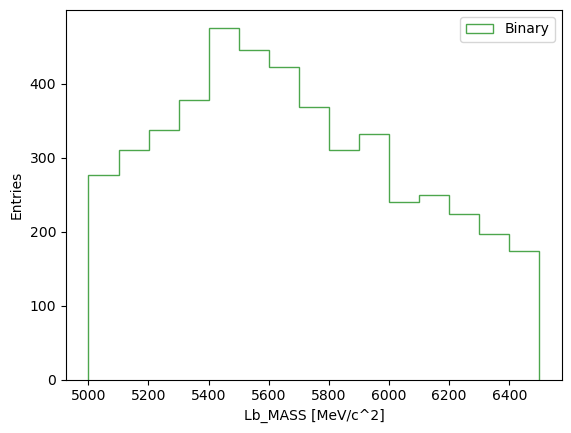

In [7]:
fig, axes = plt.subplots()

hist1, bins1, _ = axes.hist(mc_signal_background.query('(L_BKGCAT ==100)')['Lb_MASS'],bins=15,label='Binary',color='green',alpha=0.7,histtype='step')

# Set labels and legend
plt.xlabel('Lb_MASS [MeV/c^2]')

plt.ylabel('Entries')
plt.legend()
plt.show()


In [8]:
mc_signal_background

,L_MASS,Lb_MASS,Jpsi_MASS,Jpsi_P,Jpsi_PT,Jpsi_CHI2,Jpsi_MAXDOCA,Jpsi_BPVDIRA,Jpsi_ETA,Jpsi_END_VRHO,...,pim_TRACK_POS_CLOSESTTOBEAM_Y,pim_TRACK_POS_CLOSESTTOBEAM_Z,L_BKGCAT,SUMCHI2,Theta_P,Cos_theta_P,Cos_xi_LP,Cos_xi_LbP,xi_LP,xi_LbP
0,1078.216064,5238.732910,3095.558350,48452.062500,915.653381,0.299717,0.015202,0.999958,4.661691,1.093754,...,-184.4296,7826.0991,-1,1.753419,0.130001,0.991562,0.999636,0.999350,0.036062,0.026965
1,1078.259033,5257.361816,3014.794678,145656.640625,6167.957520,0.607561,0.013176,0.999846,3.854582,1.118636,...,-192.9450,7826.0991,0,4.277021,0.043999,0.999032,0.999827,0.999684,0.025122,0.018593
3,1078.478394,5378.423828,3104.240234,107524.718750,6373.708984,0.386113,0.031794,0.999907,3.517729,1.743110,...,-336.3848,7826.0991,0,1.265592,0.156578,0.987767,0.999999,0.999912,0.013256,0.001145
4,1078.545044,5452.856934,3114.653809,75249.507812,12491.000000,2.606676,0.030760,0.998852,2.481976,1.256283,...,-344.7611,7826.0991,0,22.678582,0.095915,0.995404,0.999990,0.999183,0.040418,0.004367
6,1078.846558,5150.160645,3109.953369,58382.671875,2565.219727,1.778421,0.030807,0.999737,3.817639,1.657983,...,218.3457,7895.8999,0,5.225974,0.110724,0.993876,0.999997,0.999598,0.028365,0.002367
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84570,1499.883911,5265.855957,3084.762695,132888.046875,10739.597656,0.485401,0.010115,0.999922,3.207058,1.125813,...,308.9467,7826.0991,100,22.149751,0.048605,0.998819,0.998470,0.997399,0.072146,0.055319
84572,1499.900757,6274.045410,3093.760742,187995.843750,10168.649414,0.415145,0.010528,0.999971,3.609441,3.149061,...,26.6823,7826.0991,60,1.717956,0.046903,0.998900,0.999697,0.998447,0.055737,0.024602
84573,1499.929565,5091.160156,3074.888672,41649.480469,687.273193,0.797971,0.025173,0.999358,4.797313,1.199297,...,-146.1894,7826.0991,100,3.418939,0.152789,0.988351,0.999137,0.999035,0.043928,0.041540
84574,1499.931030,5535.737793,3085.348389,111571.656250,9278.409180,0.000240,0.000333,0.999950,3.178382,1.791836,...,305.8184,7895.8999,60,8.222278,0.070174,0.997539,0.999887,0.999442,0.033418,0.015030


In [9]:
model = CatBoostClassifier().load_model("new_BDT")

In [10]:
model.feature_names_

['Jpsi_PT',
 'L_END_VRHO',
 'L_BPVDIRA',
 'L_BPVIP',
 'L_BPVIPCHI2',
 'Lb_BPVDIRA',
 'Lb_BPVIP',
 'Lb_BPVVDRHO',
 'Lb_MAXDOCA',
 'Lb_P',
 'Lb_PT',
 'Lb_CHI2',
 'p_PID_P',
 'p_MINIP',
 'mup_PID_MU',
 'L_PT',
 'Jpsi_MAXDOCA',
 'Lb_MINIPCHI2',
 'L_P',
 'Jpsi_BPVDIRA',
 'L_CHI2',
 'Lb_ETA',
 'L_END_VZ',
 'L_END_VX',
 'L_END_VY',
 'Jpsi_ETA',
 'p_P',
 'p_PT',
 'p_ETA',
 'p_GHOSTPROB',
 'pim_P',
 'pim_PT',
 'pim_ETA',
 'pim_GHOSTPROB',
 'SUMCHI2',
 'xi_LbP',
 'xi_LP']

In [11]:

prob = model.predict_proba(mc_signal_background)
print(prob)

signal_MVA_prob_eval = prob
signal_MVA_probs = [1 - i[0] for i in signal_MVA_prob_eval]
mc_signal_background['prob1'] = signal_MVA_probs

model2 = CatBoostClassifier().load_model("new_BDT_multiclass")
prob2 = model2.predict_proba(mc_signal_background)
print(prob2)

signal_MVA_prob_eval2 = prob2
signal_MVA_probs2 = [1 - i[0] for i in signal_MVA_prob_eval2]
mc_signal_background['prob2'] = signal_MVA_probs2

[[9.97514993e-01 2.48500704e-03]
 [1.52614032e-02 9.84738597e-01]
 [8.03558930e-05 9.99919644e-01]
 ...
 [9.99990678e-01 9.32247402e-06]
 [9.95443778e-01 4.55622215e-03]
 [8.31660911e-03 9.91683391e-01]]
[[9.91890205e-01 8.10979530e-03]
 [1.03825112e-02 9.89617489e-01]
 [3.43778677e-04 9.99656221e-01]
 ...
 [9.99141483e-01 8.58517149e-04]
 [9.83458093e-01 1.65419069e-02]
 [1.42617011e-02 9.85738299e-01]]


/tmp/javeser/ipykernel_2052/2862699766.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  mc_signal_background['prob1'] = signal_MVA_probs
/tmp/javeser/ipykernel_2052/2862699766.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mc_signal_background['prob1'] = signal_MVA_probs
/tmp/javeser/ipykernel_2052/2862699766.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.conc

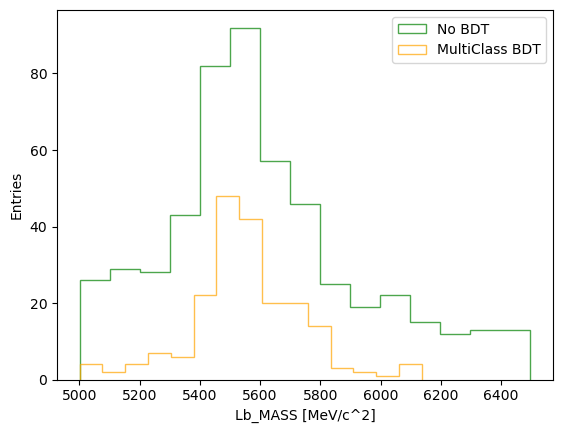

In [12]:
# Create the figure and axes
fig, axes = plt.subplots()
hist1, bins1, _ = axes.hist(mc_signal_background.query('(L_BKGCAT ==40)')['Lb_MASS'],bins=15,label='No BDT',color='green',alpha=0.7,histtype='step')
hist2, bins2, _ = axes.hist(mc_signal_background.query('(prob2 > 0.95) & (L_BKGCAT ==40)')['Lb_MASS'],bins=15,label='MultiClass BDT',color='orange',alpha=0.7,histtype='step')
# Set labels and legend
plt.xlabel('Lb_MASS [MeV/c^2]')

plt.ylabel('Entries')
plt.legend()
plt.show()

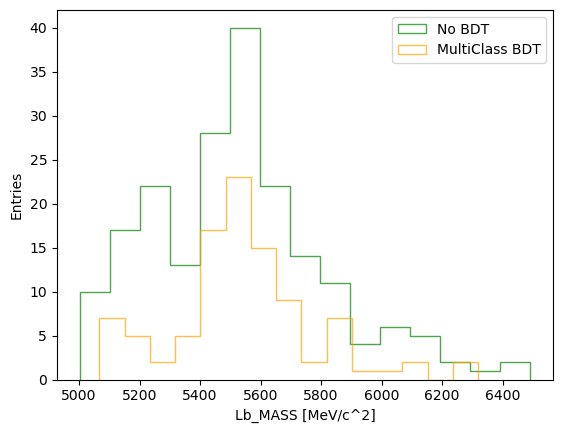

In [13]:
# Create the figure and axes
fig, axes = plt.subplots()
hist1, bins1, _ = axes.hist(mc_signal_background.query(' (L_BKGCAT ==50)')['Lb_MASS'],bins=15,label='No BDT',color='green',alpha=0.7,histtype='step')
hist2, bins2, _ = axes.hist(mc_signal_background.query('(prob2 > 0.95) & (L_BKGCAT ==50)')['Lb_MASS'],bins=15,label='MultiClass BDT',color='orange',alpha=0.7,histtype='step')
# Set labels and legend
plt.xlabel('Lb_MASS [MeV/c^2]')

plt.ylabel('Entries')
plt.legend()
plt.show()

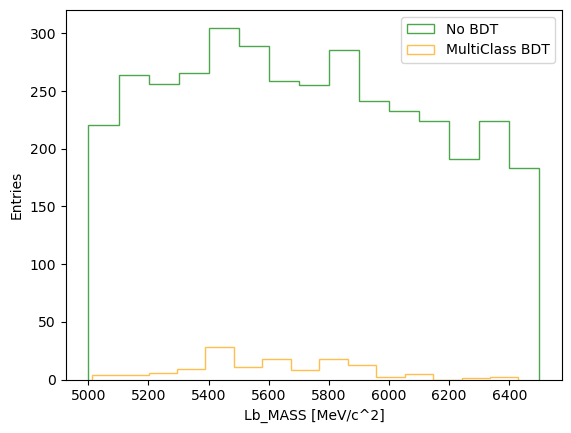

In [14]:
# Create the figure and axes
fig, axes = plt.subplots()
hist1, bins1, _ = axes.hist(mc_signal_background.query(' (L_BKGCAT ==60)')['Lb_MASS'],bins=15,label='No BDT',color='green',alpha=0.7,histtype='step')
hist2, bins2, _ = axes.hist(mc_signal_background.query('(prob2 > 0.95) & (L_BKGCAT ==60)')['Lb_MASS'],bins=15,label='MultiClass BDT',color='orange',alpha=0.7,histtype='step')
# Set labels and legend
plt.xlabel('Lb_MASS [MeV/c^2]')

plt.ylabel('Entries')
plt.legend()
plt.show()

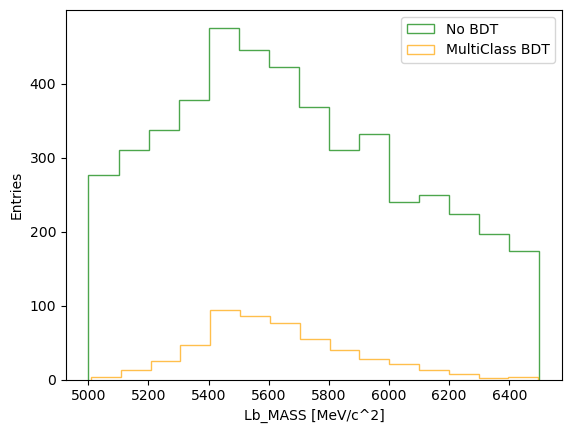

In [15]:
# Create the figure and axes
fig, axes = plt.subplots()
hist1, bins1, _ = axes.hist(mc_signal_background.query(' (L_BKGCAT ==100)')['Lb_MASS'],bins=15,label='No BDT',color='green',alpha=0.7,histtype='step')
hist2, bins2, _ = axes.hist(mc_signal_background.query('(prob2 > 0.95) & (L_BKGCAT ==100)')['Lb_MASS'],bins=15,label='MultiClass BDT',color='orange',alpha=0.7,histtype='step')
# Set labels and legend
plt.xlabel('Lb_MASS [MeV/c^2]')

plt.ylabel('Entries')
plt.legend()
plt.show()

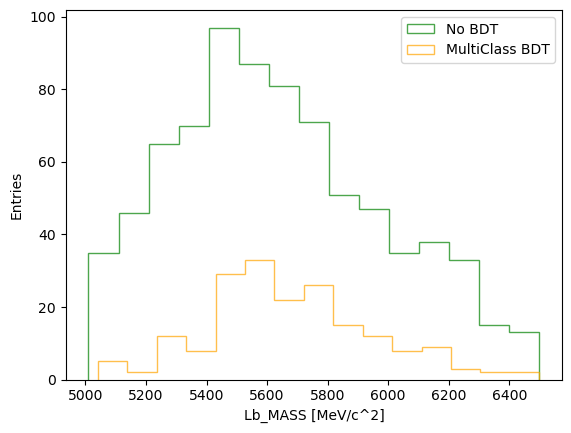

In [16]:
# Create the figure and axes
fig, axes = plt.subplots()
hist1, bins1, _ = axes.hist(mc_signal_background.query(' (L_BKGCAT ==110)')['Lb_MASS'],bins=15,label='No BDT',color='green',alpha=0.7,histtype='step')
hist2, bins2, _ = axes.hist(mc_signal_background.query('(prob2 > 0.95) & (L_BKGCAT ==110)')['Lb_MASS'],bins=15,label='MultiClass BDT',color='orange',alpha=0.7,histtype='step')
# Set labels and legend
plt.xlabel('Lb_MASS [MeV/c^2]')

plt.ylabel('Entries')
plt.legend()
plt.show()

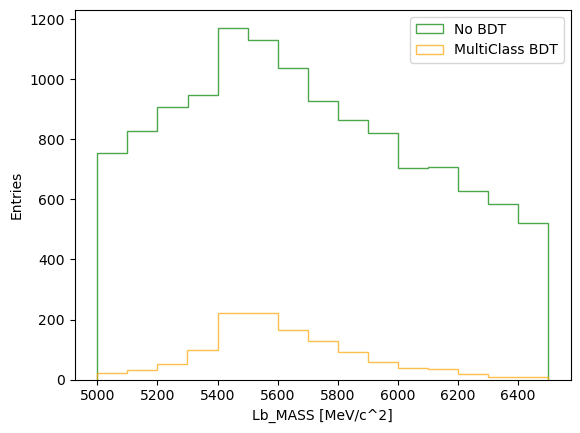

In [17]:
# Create the figure and axes
density = 'False'
fig, axes = plt.subplots()
hist1, bins1, _ = axes.hist(mc_signal_background.query(' (L_BKGCAT !=0)')['Lb_MASS'],bins=15,label='No BDT',color='green',alpha=0.7,histtype='step')
hist2, bins2, _ = axes.hist(mc_signal_background.query('(prob2 > 0.95) & (L_BKGCAT !=0)')['Lb_MASS'],bins=15,label='MultiClass BDT',color='orange',alpha=0.7,histtype='step')
# Set labels and legend
plt.xlabel('Lb_MASS [MeV/c^2]')

plt.ylabel('Entries')
plt.legend()

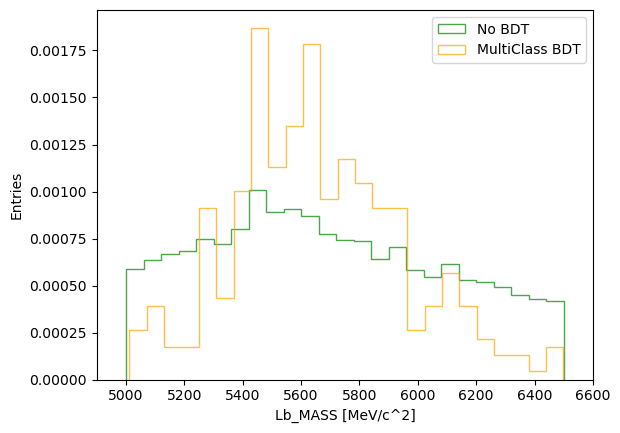

In [20]:
# Create the figure and axes
density = 'False'
fig, axes = plt.subplots()
hist1, bins1, _ = axes.hist(mc_signal_background.query(' (L_BKGCAT !=0)')['Lb_MASS'],bins=25,label='No BDT',color='green',alpha=0.7,histtype='step', density = 'True')
hist2, bins2, _ = axes.hist(mc_signal_background.query('(prob2 > 0.95) & (L_BKGCAT !=0)& (L_BKGCAT !=50)& (L_BKGCAT !=40)& (L_BKGCAT !=100)')['Lb_MASS'],bins=25,label='MultiClass BDT',color='orange',alpha=0.7,histtype='step', density = 'True')
# hist2, bins2, _ = axes.hist(mc_signal_background.query('(L_BKGCAT !=0)& (L_BKGCAT !=50)& (L_BKGCAT !=40')['Lb_MASS'],bins=15,label='MultiClass BDT',color='orange',alpha=0.7,histtype='step', density='True')

# Set labels and legend
plt.xlabel('Lb_MASS [MeV/c^2]')
axes.set_xlim(4900, 6600)
plt.ylabel('Entries')
plt.legend()